In [1]:
import os

print(os.getcwd())

c:\Users\Greesha Vaishnavi\Desktop\dsprojects\Hotel_Booking_Cancellation_Prediction\research\model_experiments


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    log_loss
)

In [3]:
import pandas as pd

train_df = pd.read_csv(
    "../../artifacts/data_transformation/train.csv"
)

test_df = pd.read_csv(
    "../../artifacts/data_transformation/test.csv"
)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (95512, 917)
Test shape : (23878, 917)


In [4]:
target_column = "is_canceled"

X_train = train_df.drop(
    columns=[target_column]
)

y_train = train_df[target_column]

X_test = test_df.drop(
    columns=[target_column]
)

y_test = test_df[target_column]

In [6]:
print("X_train shape:", X_train.shape)  #check our transformed data
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (95512, 916)
X_test shape : (23878, 916)
y_train shape: (95512,)
y_test shape : (23878,)


In [7]:
print("Training target distribution:")     # check target distribution
print(y_train.value_counts())

print("\nTraining target percentage:")
print(y_train.value_counts(normalize=True) * 100)

Training target distribution:
is_canceled
0    60133
1    35379
Name: count, dtype: int64

Training target percentage:
is_canceled
0    62.958581
1    37.041419
Name: proportion, dtype: float64


In [8]:
logistic_model = LogisticRegression(                 # baseline logistic regression
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=2000,
    class_weight=None
)

In [9]:
logistic_model.fit(                                # model train
    X_train,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [10]:
print("Number of iterations:", logistic_model.n_iter_)   # checking convergence

Number of iterations: [230]


In [11]:
print("Intercept shape:", logistic_model.intercept_.shape)
print("Coefficient shape:", logistic_model.coef_.shape)     # check model coeff

Intercept shape: (1,)
Coefficient shape: (1, 916)


In [12]:
y_pred = logistic_model.predict(X_test)  # make predictions

print(y_pred[:20])

[0 0 1 0 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1]


In [13]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]  # make probabilities

print(y_prob[:20])

[0.0847306  0.1006773  0.64547507 0.00492522 0.28040052 0.99463783
 0.99821455 0.67681002 0.34321234 0.01270624 0.1243692  0.20256811
 0.70267829 0.36189469 0.57058219 0.01297751 0.06471184 0.99311104
 0.12021724 0.99929459]


In [14]:
cm = confusion_matrix(              # evaluate confusion matrix
    y_test,
    y_pred
)

print(cm)

[[13601  1432]
 [ 2562  6283]]


In [15]:
tn, fp, fn, tp = cm.ravel()              #Extract TN, FP, FN, TP

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 13601
False Positive: 1432
False Negative: 2562
True Positive : 6283


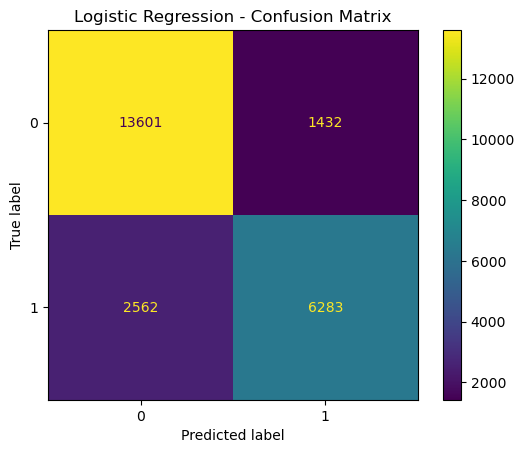

In [ ]:
ConfusionMatrixDisplay.from_predictions(          #Visualize confusion matrix
    y_test, 
    y_pred
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
accuracy = accuracy_score(                     # evaluate Accuracy
    y_test,
    y_pred
)

print("Accuracy:", accuracy)
print("Accuracy %:", accuracy * 100)

Accuracy: 0.8327330597202446
Accuracy %: 83.27330597202446


In [18]:
precision = precision_score(                   # evaluate precision
    y_test,
    y_pred,
    zero_division=0
)

print("Precision:", precision)

Precision: 0.8143875567077122


In [19]:
recall = recall_score(                     # recall
    y_test,
    y_pred,
    zero_division=0
)

print("Recall:", recall)

Recall: 0.7103448275862069


In [20]:
f1 = f1_score(                         # evaluate f1
    y_test,
    y_pred,
    zero_division=0
)

print("F1 Score:", f1)

F1 Score: 0.758816425120773


In [21]:
specificity = tn / (tn + fp)             # specificity

print("Specificity:", specificity)

Specificity: 0.904742898955631


In [22]:
print(
    classification_report(            # it gives all precision,recall, f1score,support
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87     15033
           1       0.81      0.71      0.76      8845

    accuracy                           0.83     23878
   macro avg       0.83      0.81      0.82     23878
weighted avg       0.83      0.83      0.83     23878



In [23]:
fpr, tpr, thresholds = roc_curve(                # roc curve
    y_test,
    y_prob
)

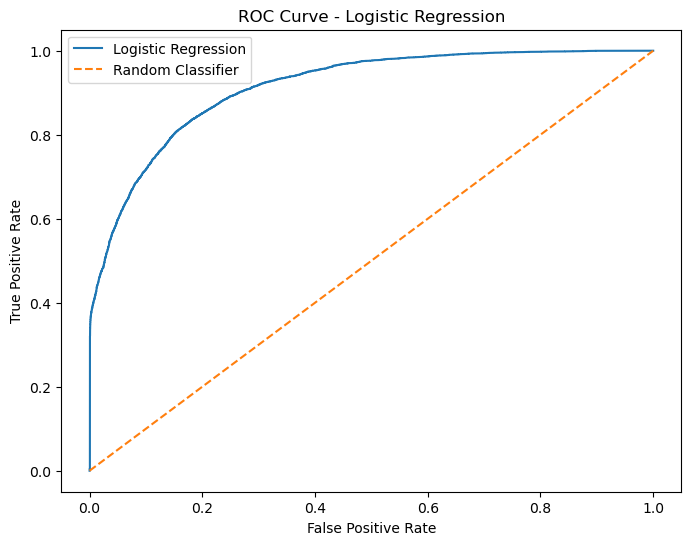

In [24]:
plt.figure(figsize=(8, 6))        # plot roc curve

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

In [25]:
roc_auc = roc_auc_score(                    # roc_auc
    y_test,
    y_prob
)

print("ROC-AUC:", roc_auc)

roc_auc

ROC-AUC: 0.9128504589695396


0.9128504589695396

In [27]:
precision_values, recall_values, pr_thresholds = precision_recall_curve(    # precision_recall_curve
    y_test,
    y_prob
)

precision_values, recall_values, pr_thresholds

(array([0.37042466, 0.37044017, 0.37045569, ..., 1.        , 1.        ,
        1.        ], shape=(19848,)),
 array([1.        , 1.        , 1.        , ..., 0.00384398, 0.0035048 ,
        0.        ], shape=(19848,)),
 array([1.81369528e-22, 1.14286145e-21, 1.30070241e-21, ...,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00], shape=(19847,)))

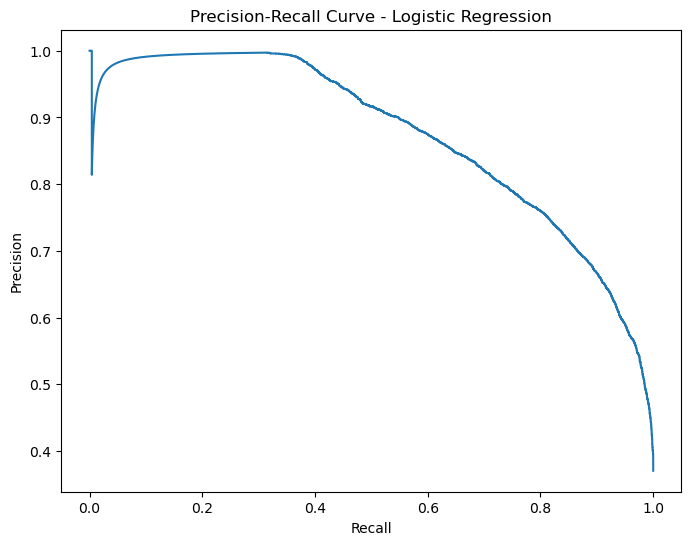

In [28]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")

plt.show()

In [29]:
pr_auc = average_precision_score(
    y_test,
    y_prob
)

print("PR-AUC:", pr_auc)

PR-AUC: 0.8725727071346087


In [ ]:
logloss = log_loss(                  # logloss lower logloss is better
    y_test,
    y_prob
)

print("Log Loss:", logloss)

Log Loss: 0.35736944173576185


In [ ]:
print("=" * 50)
print("LOGISTIC REGRESSION - BASELINE EVALUATION") 
print("=" * 50)

print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1 Score    : {f1:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")
print(f"PR-AUC      : {pr_auc:.4f}")
print(f"Log Loss    : {logloss:.4f}")

LOGISTIC REGRESSION - BASELINE EVALUATION
Accuracy    : 0.8327
Precision   : 0.8144
Recall      : 0.7103
Specificity : 0.9047
F1 Score    : 0.7588
ROC-AUC     : 0.9129
PR-AUC      : 0.8726
Log Loss    : 0.3574


the above we will name as model A

In [32]:
logistic_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "Specificity": [specificity],
    "F1 Score": [f1],
    "ROC-AUC": [roc_auc],
    "PR-AUC": [pr_auc],
    "Log Loss": [logloss]
})

logistic_results

,Model,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression,0.832733,0.814388,0.710345,0.904743,0.758816,0.91285,0.872573,0.357369


# hyperparameter tuning

Optimize F1

In [ ]:
from sklearn.model_selection import GridSearchCV       # import gridsearch 

In [ ]:
logistic_tuning_model = LogisticRegression(  #Create Logistic Regression for tuning
    max_iter=2000
)

In [36]:
param_grid = {                                # parametergrid
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "class_weight": [None, "balanced"]
}

param_grid

{'C': [0.01, 0.1, 1, 10, 100],
 'penalty': ['l2'],
 'solver': ['lbfgs'],
 'class_weight': [None, 'balanced']}

In [37]:
grid_search = GridSearchCV(                    # create gridsearchcv
    estimator=logistic_tuning_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

10 parameter combinations×5-fold cross-validation=50 model trainings

In [38]:
grid_search.fit(            # tuning model  
    X_train,
    y_train
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,LogisticRegre...max_iter=2000)
,param_grid,"{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [39]:
print("Best Parameters:")                 # print best parameters
print(grid_search.best_params_)

Best Parameters:
{'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}


In [40]:
print(                            #Best cross-validation F1
    "Best CV F1 Score:",
    grid_search.best_score_
)

#It's the mean F1 obtained during cross-validation on the training data

Best CV F1 Score: 0.7800561740666185


In [42]:
best_logistic_model = grid_search.best_estimator_

In [43]:
best_logistic_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}


In [44]:
tuned_pred = best_logistic_model.predict(    #predictions
    X_test
)

tuned_prob = best_logistic_model.predict_proba(
    X_test
)[:, 1]

In [45]:
tuned_accuracy = accuracy_score(                # evaluate tuned models
    y_test,
    tuned_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_pred,
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    tuned_pred,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    tuned_pred,
    zero_division=0
)

tuned_roc_auc = roc_auc_score(
    y_test,
    tuned_prob
)

tuned_pr_auc = average_precision_score(
    y_test,
    tuned_prob
)

tuned_logloss = log_loss(
    y_test,
    tuned_prob
)

tn_t, fp_t, fn_t, tp_t = confusion_matrix(
    y_test,
    tuned_pred
).ravel()

tuned_specificity = tn_t / (tn_t + fp_t)

In [46]:
print("=" * 55)
print("TUNED LOGISTIC REGRESSION")          # print results
print("=" * 55)

print(f"Accuracy    : {tuned_accuracy:.4f}")
print(f"Precision   : {tuned_precision:.4f}")
print(f"Recall      : {tuned_recall:.4f}")
print(f"Specificity : {tuned_specificity:.4f}")
print(f"F1 Score    : {tuned_f1:.4f}")
print(f"ROC-AUC     : {tuned_roc_auc:.4f}")
print(f"PR-AUC      : {tuned_pr_auc:.4f}")
print(f"Log Loss    : {tuned_logloss:.4f}")

TUNED LOGISTIC REGRESSION
Accuracy    : 0.8280
Precision   : 0.7419
Recall      : 0.8214
Specificity : 0.8318
F1 Score    : 0.7796
ROC-AUC     : 0.9126
PR-AUC      : 0.8702
Log Loss    : 0.3741


the model we will consider model B

In [47]:
comparison = pd.DataFrame({           # Compare baseline vs tuned
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss"
    ],
    
    "Baseline": [
        accuracy,
        precision,
        recall,
        specificity,
        f1,
        roc_auc,
        pr_auc,
        logloss
    ],
    
    "Tuned": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_specificity,
        tuned_f1,
        tuned_roc_auc,
        tuned_pr_auc,
        tuned_logloss
    ]
})

comparison

,Metric,Baseline,Tuned
0,Accuracy,0.832733,0.827959
1,Precision,0.814388,0.741856
2,Recall,0.710345,0.821368
3,Specificity,0.904743,0.831837
4,F1 Score,0.758816,0.779590
5,ROC-AUC,0.912850,0.912617
6,PR-AUC,0.872573,0.870170
7,Log Loss,0.357369,0.374125


# hyperparameter 2

Optimize Accuracy

In [48]:
accuracy_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "class_weight": [None]
}

In [49]:
accuracy_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=2000
    ),
    param_grid=accuracy_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

In [50]:
accuracy_grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,estimator,LogisticRegre...max_iter=2000)
,param_grid,"{'C': [0.001, 0.01, ...], 'class_weight': [None], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


6 parameter combinations×5 folds of cross validation=30 fits

In [51]:
print("Best Accuracy Parameters:")
print(accuracy_grid_search.best_params_)

print(
    "Best CV Accuracy:",
    accuracy_grid_search.best_score_
)

Best Accuracy Parameters:
{'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Accuracy: 0.8332774666326903


In [52]:
best_accuracy_model = (
    accuracy_grid_search.best_estimator_
)

In [53]:
accuracy_pred = best_accuracy_model.predict(
    X_test
)

accuracy_prob = best_accuracy_model.predict_proba(
    X_test
)[:, 1]

In [56]:
accuracy_model_score = accuracy_score(
    y_test,
    accuracy_pred
)

accuracy_model_precision = precision_score(
    y_test,
    accuracy_pred,
    zero_division=0
)

accuracy_model_recall = recall_score(
    y_test,
    accuracy_pred,
    zero_division=0
)

accuracy_model_f1 = f1_score(
    y_test,
    accuracy_pred,
    zero_division=0
)

accuracy_model_roc_auc = roc_auc_score(
    y_test,
    accuracy_prob
)

accuracy_cm = confusion_matrix(
    y_test,
    accuracy_pred
)

tn_acc, fp_acc, fn_acc, tp_acc = accuracy_cm.ravel()

accuracy_model_specificity = (
    tn_acc / (tn_acc + fp_acc)
)

accuracy_model_pr_auc = average_precision_score(
    y_test,
    accuracy_prob
)

accuracy_model_logloss = log_loss(
    y_test,
    accuracy_prob
)


print("=" * 50)
print("ACCURACY-TUNED LOGISTIC REGRESSION")
print("=" * 50)

print("Accuracy    :", accuracy_model_score)
print("Precision   :", accuracy_model_precision)
print("Recall      :", accuracy_model_recall)
print("Specificity :", accuracy_model_specificity)
print("F1 Score    :", accuracy_model_f1)
print("ROC-AUC     :", accuracy_model_roc_auc)
print("PR-AUC      :", accuracy_model_pr_auc)
print("Log Loss    :", accuracy_model_logloss)

ACCURACY-TUNED LOGISTIC REGRESSION
Accuracy    : 0.8323561437306307
Precision   : 0.8120649651972158
Recall      : 0.7122668174109666
Specificity : 0.9030133705847136
F1 Score    : 0.7588989941576824
ROC-AUC     : 0.9125290405953331
PR-AUC      : 0.8723678058291857
Log Loss    : 0.35820009405441994


the model we will consider model C

In [57]:
logistic_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss"
    ],

    "Baseline": [
        accuracy,
        precision,
        recall,
        specificity,
        f1,
        roc_auc,
        pr_auc,
        logloss
    ],

    "F1-Tuned": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_specificity,
        tuned_f1,
        tuned_roc_auc,
        tuned_pr_auc,
        tuned_logloss
    ],

    "Accuracy-Tuned": [
        accuracy_model_score,
        accuracy_model_precision,
        accuracy_model_recall,
        accuracy_model_specificity,
        accuracy_model_f1,
        accuracy_model_roc_auc,
        accuracy_model_pr_auc,
        accuracy_model_logloss
    ]
})

logistic_comparison

,Metric,Baseline,F1-Tuned,Accuracy-Tuned
0,Accuracy,0.832733,0.827959,0.832356
1,Precision,0.814388,0.741856,0.812065
2,Recall,0.710345,0.821368,0.712267
3,Specificity,0.904743,0.831837,0.903013
4,F1 Score,0.758816,0.779590,0.758899
5,ROC-AUC,0.912850,0.912617,0.912529
6,PR-AUC,0.872573,0.870170,0.872368
7,Log Loss,0.357369,0.374125,0.358200


Hyperparameter tuning was performed using 5-fold cross-validation. Optimizing F1 improved recall and F1-score, but reduced precision and accuracy. Accuracy-based tuning produced performance very close to the baseline. Therefore, the baseline Logistic Regression model provides the best overall balance for this experiment, while the F1-optimized model may be preferred when detecting more cancellation cases is the priority.